In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from pathlib import Path

In [71]:
repo_path = Path('../..')
sim_results_folder = repo_path / 'simulation_results'/'dFBA'

In [72]:
si = 102
cs = 'Malate'
fn = sim_results_folder / f'sol_s_minimal_{si}_{cs}.tsv.gz'
df = pd.read_csv(fn, sep='\t', index_col=0)

In [73]:
# Remove duplicated timepoints (biomass is recorded both at the end of start of a batch, e.g. at T=72)
df = df.loc[~df['time'].duplicated()].copy()

In [74]:
species = ['At', 'Ct', 'Ml', 'Oa']

In [75]:
df.rename(columns={s.lower(): s for s in species}, inplace=True)

In [76]:
df_species = df.melt(id_vars=['time'], value_vars=species, var_name='species', value_name='abundance')

In [77]:
tab10 = sns.palettes.color_palette('tab10')
palette = {'At': tab10[2],
           'Ct': tab10[1],
           'Ml':tab10[0],
           'Oa':tab10[3]}

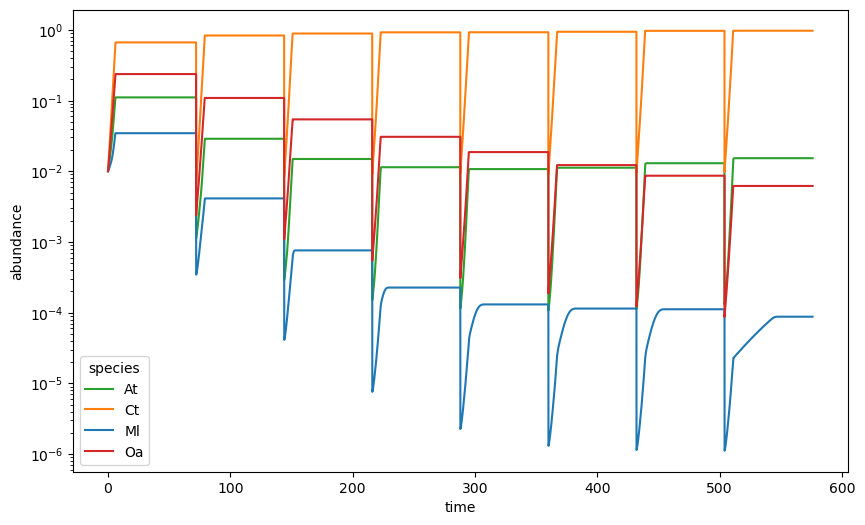

In [78]:

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df_species, x='time', y='abundance', hue='species', ax = ax, palette=palette)
plt.yscale('log')


# Read in all final abundances

In [80]:
fn_final = sim_results_folder / 'finalAbundances.tsv'
dfF = pd.read_csv(fn_final, sep='\t', index_col=0)

In [106]:
dfF.rename(columns={s.lower(): s for s in species}, inplace=True)

In [110]:
dfF = dfF.loc[dfF[species].max(axis = 1) < 10]

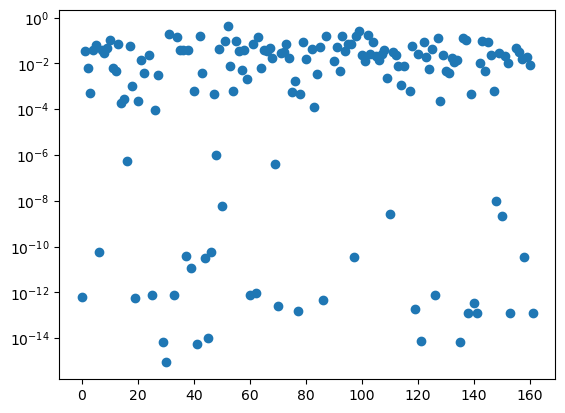

In [116]:
plt.scatter(y = dfF['Oa'], x = dfF.index)
plt.yscale('log')

<Axes: xlabel='At', ylabel='Density'>

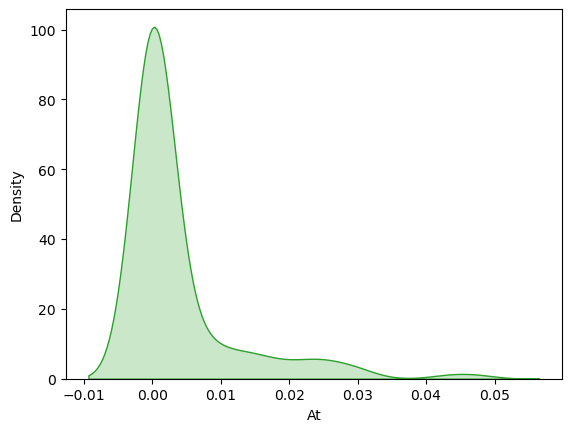

In [118]:
sns.kdeplot(data=dfF, x='At', fill=True, label='At', color=palette['At'])

In [ ]:
# Create KDE plot in log10-space for all species
fig, ax = plt.subplots(figsize=(10, 6))

for sp in species:
    # Transform to log10, filtering out zeros/negatives
    log_values = np.log10(dfF[sp][dfF[sp] > 0])
    
    # Plot KDE
    sns.kdeplot(data=log_values, fill=True, alpha=0.5, label=sp.upper(), 
                color=palette[sp.capitalize()], ax=ax)

ax.set_xlabel('log10(Abundance)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('KDE of Final Species Abundances (log10-space)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Alternative: KDE with log-scale x-axis (plots in original space with log scale)
fig, ax = plt.subplots(figsize=(10, 6))

for sp in species:
    # Filter out zeros/negatives
    values = dfF[sp][dfF[sp] > 0]
    
    # Plot KDE in original space
    sns.kdeplot(data=values, fill=True, alpha=0.5, label=sp.upper(), 
                color=palette[sp.capitalize()], ax=ax, log_scale=True)

ax.set_xlabel('Abundance', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('KDE of Final Species Abundances (log-scale)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()